## One Image per class

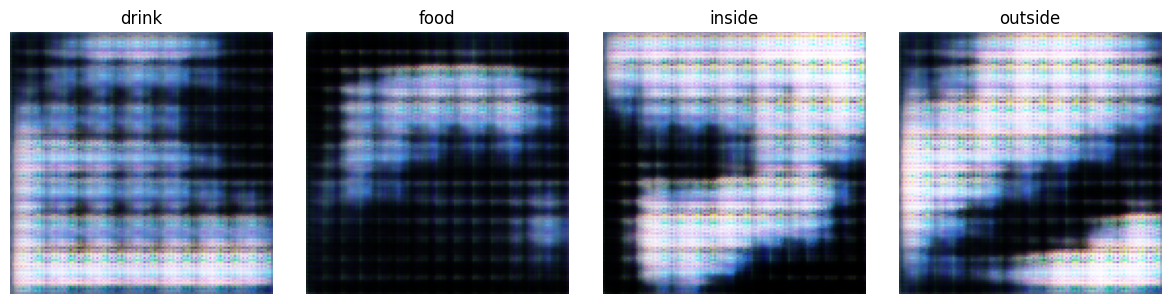

In [20]:
generate_images_by_label(generator, class_names)

## Install Required Packages

In [21]:
!pip install tensorflow matplotlib scipy


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\gauch\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


##Imports and Constants

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from scipy.stats import entropy
import numpy as np
import matplotlib.pyplot as plt
import os
import time

## Configurations

In [26]:
# Options: "fast", "balanced", "full"
MODE = "balanced"

# ========== FIXED SETTINGS ==========
IMG_CHANNELS = 3
DATA_PATH = "../data/final_processed_data/train"
NUM_CLASSES = 4
LATENT_DIM = 100
SAVE_MODEL = True
SAVE_IMAGES_EACH_EPOCH = True
MODEL_SAVE_PATH = "cgan_generator_final.h5"

# ========== FAST MODE ==========
if MODE == "fast":
    IMG_HEIGHT = 112
    IMG_WIDTH = 112
    BATCH_SIZE = 32
    EPOCHS = 3
    LIMIT_BATCHES = 30  # ~5-10 mins
    MODEL_SAVE_PATH = "cgan_generator_final_fast.h5"

# ========== BALANCED MODE (RECOMMENDED) ==========
elif MODE == "balanced":
    IMG_HEIGHT = 128
    IMG_WIDTH = 128
    BATCH_SIZE = 32
    EPOCHS = 10
    LIMIT_BATCHES = 100  # ~30-40 mins
    MODEL_SAVE_PATH = "cgan_generator_final_balanced.h5"

# ========== FULL MODE ==========
elif MODE == "full":
    IMG_HEIGHT = 224
    IMG_WIDTH = 224
    BATCH_SIZE = 64
    EPOCHS = 50
    LIMIT_BATCHES = None
    MODEL_SAVE_PATH = "cgan_generator_final_full.h5"

else:
    raise ValueError("❌ Invalid MODE. Choose from: 'fast', 'balanced', 'full'")

##Load and Preprocess Dataset

In [27]:
# Load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    label_mode='int',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Store class names early
class_names = train_ds.class_names

# Normalize to [-1, 1]
def preprocess(images, labels):
    images = tf.cast(images, tf.float32)
    images = (images / 127.5) - 1.0
    return images, labels

train_ds = train_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)

# Optional: sample subset
if LIMIT_BATCHES:
    train_ds = train_ds.take(LIMIT_BATCHES)


Found 18599 files belonging to 4 classes.


## Generator

In [28]:
from tensorflow.keras import layers, Model, Input

def build_generator(latent_dim=100, num_classes=4, img_shape=(128, 128, 3)):
    noise_input = Input(shape=(latent_dim,), name="noise_input")
    label_input = Input(shape=(1,), dtype='int32', name="label_input")

    # Embed label and combine with noise
    label_embedding = layers.Embedding(num_classes, latent_dim)(label_input)
    label_embedding = layers.Flatten()(label_embedding)
    conditioned_input = layers.Multiply()([noise_input, label_embedding])

    x = layers.Dense(7 * 7 * 256, use_bias=False)(conditioned_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Reshape((7, 7, 256))(x)

    x = layers.Conv2DTranspose(128, kernel_size=5, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(32, kernel_size=5, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Final layer to get 3-channel output (tanh activation)
    x = layers.Conv2DTranspose(3, kernel_size=5, strides=2, padding='same', activation='tanh')(x)

    # ✅ Resize using Keras-compatible layer
    x = layers.Resizing(img_shape[0], img_shape[1])(x)

    generator = Model([noise_input, label_input], x, name="Generator")
    return generator

##Discriminator

In [29]:
def build_discriminator(num_classes=NUM_CLASSES, img_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    image_input = layers.Input(shape=img_shape)
    label_input = layers.Input(shape=(1,), dtype='int32')

    label_embedding = layers.Embedding(num_classes, img_shape[0] * img_shape[1])(label_input)
    label_embedding = layers.Reshape((img_shape[0], img_shape[1], 1))(label_embedding)

    x = layers.Concatenate()([image_input, label_embedding])

    x = layers.Conv2D(64, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1, activation='sigmoid')(x)

    return models.Model([image_input, label_input], x, name="Discriminator")


## Loss, Optimizers, Training Step

In [30]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator = build_generator()
discriminator = build_discriminator()

gen_optimizer = tf.keras.optimizers.Adam(1e-4)
disc_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images, labels):
    labels = tf.cast(tf.reshape(labels, (-1, 1)), tf.int32)
    noise = tf.random.normal([tf.shape(images)[0], LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator([noise, labels], training=True)

        real_output = discriminator([images, labels], training=True)
        fake_output = discriminator([generated_images, labels], training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    mean_gen_grad = tf.reduce_mean([tf.reduce_mean(tf.abs(g)) for g in gen_grads if g is not None])
    mean_disc_grad = tf.reduce_mean([tf.reduce_mean(tf.abs(g)) for g in disc_grads if g is not None])

    return gen_loss, disc_loss, mean_gen_grad, mean_disc_grad


## Image Sampling Utility

In [31]:
def generate_and_save_images(generator, epoch, class_names):
    noise = tf.random.normal([NUM_CLASSES, LATENT_DIM])
    labels = tf.range(NUM_CLASSES)[:, tf.newaxis]
    generated_images = generator([noise, labels], training=False)
    generated_images = (generated_images + 1) / 2.0

    fig, axs = plt.subplots(1, NUM_CLASSES, figsize=(NUM_CLASSES * 2, 2))
    for i in range(NUM_CLASSES):
        axs[i].imshow(generated_images[i])
        axs[i].axis("off")
        axs[i].set_title(class_names[i])
    plt.tight_layout()
    plt.savefig(f"cgan_sample_epoch_{epoch+1}.png")
    plt.close()


## Full Training Loop

In [34]:
def train(dataset, epochs):

    gen_loss_per_epoch = []
    disc_loss_per_epoch = []
    gen_grad_norms_per_epoch = []
    disc_grad_norms_per_epoch = []

    for epoch in range(epochs):
        start = time.time()
        gen_losses, disc_losses  = [], []
        gen_grad_norms, disc_grad_norms = [], []

        for image_batch, label_batch in dataset:
            g_loss, d_loss, g_grad, d_grad = train_step(image_batch, label_batch)
            gen_losses.append(g_loss)
            disc_losses.append(d_loss)
            gen_grad_norms.append(g_grad)
            disc_grad_norms.append(d_grad)
        
        avg_gen_loss = tf.reduce_mean(gen_losses).numpy()
        avg_disc_loss = tf.reduce_mean(disc_losses).numpy()
        avg_gen_grad = tf.reduce_mean(gen_grad_norms).numpy()
        avg_disc_grad = tf.reduce_mean(disc_grad_norms).numpy()

        gen_loss_per_epoch.append(avg_gen_loss)
        disc_loss_per_epoch.append(avg_disc_loss)
        gen_grad_norms_per_epoch.append(avg_gen_grad)
        disc_grad_norms_per_epoch.append(avg_disc_grad)

        print(f"Epoch {epoch+1}/{epochs} | Gen Loss: {avg_gen_loss:.4f} | Disc Loss: {avg_disc_loss:.4f} | "
              f"Gen Grad: {avg_gen_grad:.6f} | Disc Grad: {avg_disc_grad:.6f} | Time: {time.time()-start:.2f}s")

        if SAVE_IMAGES_EACH_EPOCH:
            generate_and_save_images(generator, epoch, class_names)

    if SAVE_MODEL:
        generator.save(MODEL_SAVE_PATH)
        print(f"✅ Generator model saved to: {MODEL_SAVE_PATH}")
    
    return gen_loss_per_epoch, disc_loss_per_epoch, gen_grad_norms_per_epoch, disc_grad_norms_per_epoch


## Start Training

In [35]:
gen_loss, disc_loss, gen_grad, disc_grad = train(train_ds, EPOCHS)

Epoch 1/10 | Gen Loss: 2.8997 | Disc Loss: 0.3722 | Gen Grad: 0.252480 | Disc Grad: 0.090909 | Time: 298.16s
Epoch 2/10 | Gen Loss: 2.7603 | Disc Loss: 0.6634 | Gen Grad: 0.232911 | Disc Grad: 0.117822 | Time: 182.05s
Epoch 3/10 | Gen Loss: 2.7675 | Disc Loss: 0.3789 | Gen Grad: 0.312728 | Disc Grad: 0.101701 | Time: 185.32s
Epoch 4/10 | Gen Loss: 2.5944 | Disc Loss: 0.3683 | Gen Grad: 0.243210 | Disc Grad: 0.061479 | Time: 183.09s
Epoch 5/10 | Gen Loss: 2.2798 | Disc Loss: 0.5425 | Gen Grad: 0.445411 | Disc Grad: 0.124408 | Time: 182.59s
Epoch 6/10 | Gen Loss: 2.5587 | Disc Loss: 0.5677 | Gen Grad: 0.515455 | Disc Grad: 0.109021 | Time: 186.30s
Epoch 7/10 | Gen Loss: 2.8160 | Disc Loss: 0.3265 | Gen Grad: 0.364421 | Disc Grad: 0.078017 | Time: 185.79s
Epoch 8/10 | Gen Loss: 2.6745 | Disc Loss: 0.4847 | Gen Grad: 0.369793 | Disc Grad: 0.097568 | Time: 187.55s
Epoch 9/10 | Gen Loss: 2.4828 | Disc Loss: 0.6199 | Gen Grad: 0.360329 | Disc Grad: 0.181148 | Time: 186.44s
Epoch 10/10 | Gen L

✅ Generator model saved to: cgan_generator_final_balanced.h5


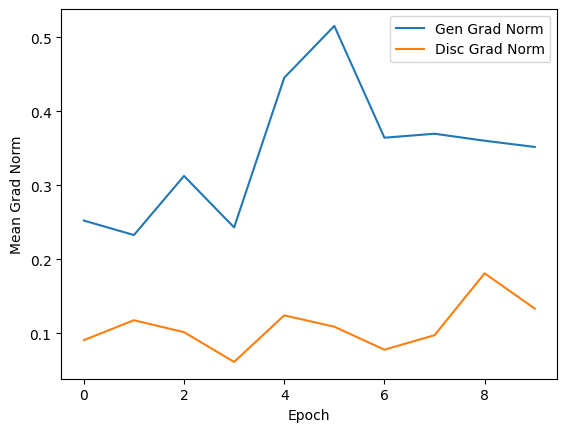

In [36]:
def plot_mean_grad():
    plt.plot(gen_grad, label="Gen Grad Norm")
    plt.plot(disc_grad, label="Disc Grad Norm")
    plt.xlabel("Epoch")
    plt.ylabel("Mean Grad Norm")
    plt.legend()
    plt.show()

plot_mean_grad()

## Generate Images for Each Label

In [37]:
def generate_images_by_label(generator, class_names, latent_dim=LATENT_DIM):
    os.makedirs("cgan_final_outputs", exist_ok=True)

    noise = tf.random.normal([NUM_CLASSES, latent_dim])
    labels = tf.range(NUM_CLASSES)[:, tf.newaxis]

    generated_images = generator([noise, labels], training=False)
    generated_images = (generated_images + 1) / 2.0  # Rescale to [0, 1]

    fig, axs = plt.subplots(1, NUM_CLASSES, figsize=(NUM_CLASSES * 3, 3))
    for i in range(NUM_CLASSES):
        axs[i].imshow(generated_images[i])
        axs[i].axis('off')
        axs[i].set_title(class_names[i])
        plt.imsave(f"cgan_final_outputs/class_{class_names[i]}.png", generated_images[i].numpy())
    plt.tight_layout()
    plt.savefig("cgan_final_outputs/cgan_generated_grid.png")
    plt.show()

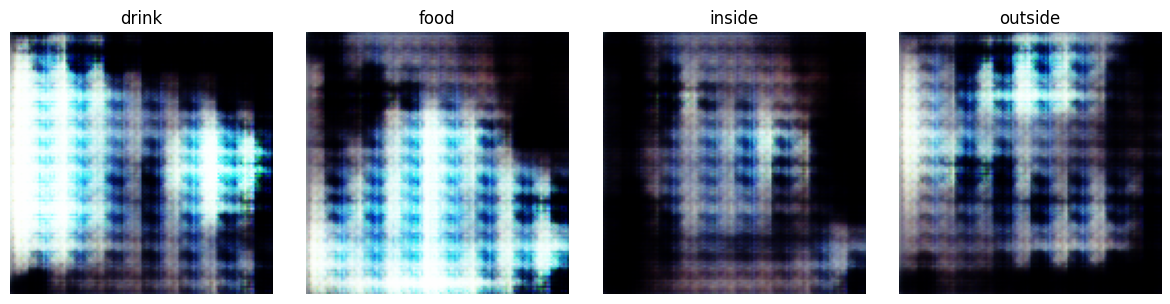

In [44]:
generate_images_by_label(generator, class_names)

## Inception Score Utility

In [ ]:
# Load pretrained InceptionV3 model
inception_model = InceptionV3(include_top=True, weights='imagenet', pooling='avg')

def calculate_inception_score(images, splits=10):
    # Step 1: Resize and preprocess
    images = tf.image.resize(images, (299, 299))
    images = preprocess_input(images * 255.0)

    # Step 2: Predict with InceptionV3
    preds = inception_model.predict(images, verbose=0)
    preds = tf.nn.softmax(preds).numpy()

    # Step 3: Split into parts and compute KL divergence
    split_scores = []
    N = preds.shape[0]
    for k in range(splits):
        part = preds[k * N // splits: (k+1) * N // splits]
        py = np.mean(part, axis=0)
        scores = [entropy(p, py) for p in part]
        split_scores.append(np.exp(np.mean(scores)))

    # Final Inception Score
    return np.mean(split_scores), np.std(split_scores)

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


## Generate Images for IS Evaluation

In [ ]:
# Generate 100 images across all labels
n_images = 100
noise = tf.random.normal([n_images, LATENT_DIM])
labels = tf.random.uniform([n_images, 1], minval=0, maxval=NUM_CLASSES, dtype=tf.int32)

generated_images = generator([noise, labels], training=False)
generated_images = (generated_images + 1.0) / 2.0  # Rescale to [0, 1]

## Compute & Print Inception Score

In [ ]:
mean_is, std_is = calculate_inception_score(generated_images, splits=5)
print(f"📈 Inception Score (IS): {mean_is:.4f} ± {std_is:.4f}")

📈 Inception Score (IS): 1.0001 ± 0.0000


#### **Tuning**

In [50]:
def plot_loss():
    plt.plot(gen_loss, label='Generator Loss')
    plt.plot(disc_loss, label='Discriminator Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('CGAN Losses per Epoch')
    plt.legend()
    plt.show()

In [ ]:
def plot_mean_grad():
    plt.plot(gen_grad, label="Gen Grad Norm")
    plt.plot(disc_grad, label="Disc Grad Norm")
    plt.xlabel("Epoch")
    plt.ylabel("Mean Grad Norm")
    plt.legend()
    plt.show()

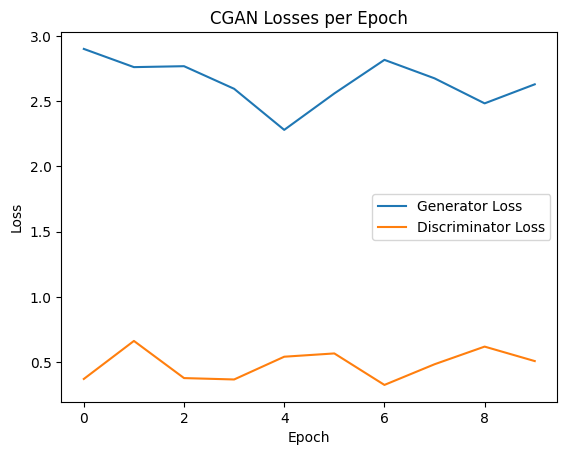

In [51]:
plot_loss()

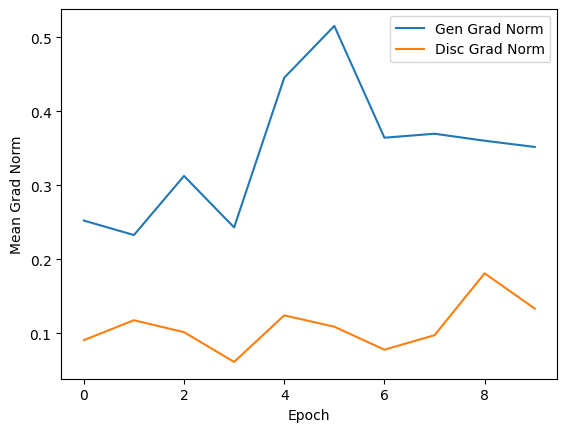

In [ ]:
plot_mean_grad()

### **Vanishing Gradient Check**

The **mean gradient norm** for both the generator and discriminator while training for 10 epoch is **always above zero** which indicates that there is **no issue of vanishing gradient**. The model is learning actively in both the networks and the **gradients are stable**.

### **Non convergence Check**

We can see some overfluctauting losses which is typical for GANs but there is **no sign  of exploding gradients or flat gradient norm** which implies that there is **no evidence of non convergence** and the training is stable where the network neither collapsed nor did the training diverged.

### **Mode collapse Check**

No evidence of mode collapse can be observed as all the **generated images are not identical** and there are some **variations among the images**. But the generated images are blurry which can be due to partial mode collapse or underfitting.

As the model was **not suffering from vanishing gradient, non convergence and mode collapse issue**, I went with two widely used **tuning approaches** i.e **Label Smoothing** and **Lowering the DropOut** to increase the model performance and training stability.

### **Tuning iteration 1 : Label Smoothing**

In [40]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output) * 0.9, real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

In [ ]:
gen_loss, disc_loss, gen_grad, disc_grad = train(train_ds, EPOCHS)

Epoch 1/10 | Gen Loss: 2.5421 | Disc Loss: 0.4669 | Gen Grad: 0.319702 | Disc Grad: 0.143906 | Time: 194.09s
Epoch 2/10 | Gen Loss: 3.0321 | Disc Loss: 0.4173 | Gen Grad: 0.296808 | Disc Grad: 0.152251 | Time: 203.97s
Epoch 3/10 | Gen Loss: 3.0278 | Disc Loss: 0.4541 | Gen Grad: 0.191780 | Disc Grad: 0.191539 | Time: 190.49s
Epoch 4/10 | Gen Loss: 2.4339 | Disc Loss: 0.5414 | Gen Grad: 0.215911 | Disc Grad: 0.187282 | Time: 188.96s
Epoch 5/10 | Gen Loss: 2.7920 | Disc Loss: 0.4298 | Gen Grad: 0.203661 | Disc Grad: 0.193408 | Time: 188.49s
Epoch 6/10 | Gen Loss: 2.4383 | Disc Loss: 0.5945 | Gen Grad: 0.203194 | Disc Grad: 0.172037 | Time: 187.41s
Epoch 7/10 | Gen Loss: 2.5577 | Disc Loss: 0.5095 | Gen Grad: 0.157249 | Disc Grad: 0.162749 | Time: 183.75s
Epoch 8/10 | Gen Loss: 2.5789 | Disc Loss: 0.7107 | Gen Grad: 0.194554 | Disc Grad: 0.170859 | Time: 185.31s
Epoch 9/10 | Gen Loss: 2.8678 | Disc Loss: 0.5054 | Gen Grad: 0.277022 | Disc Grad: 0.213595 | Time: 185.89s
Epoch 10/10 | Gen L

✅ Generator model saved to: cgan_generator_final_balanced.h5


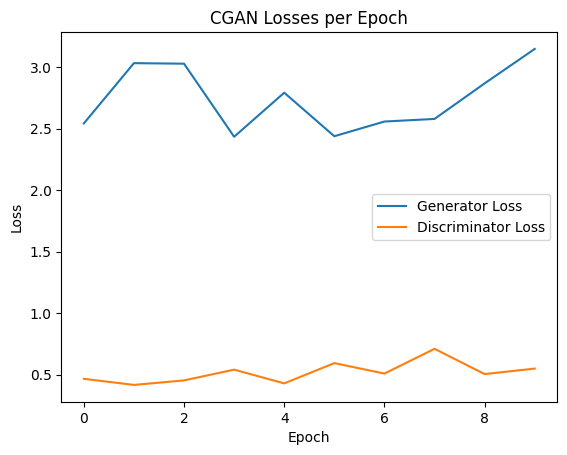

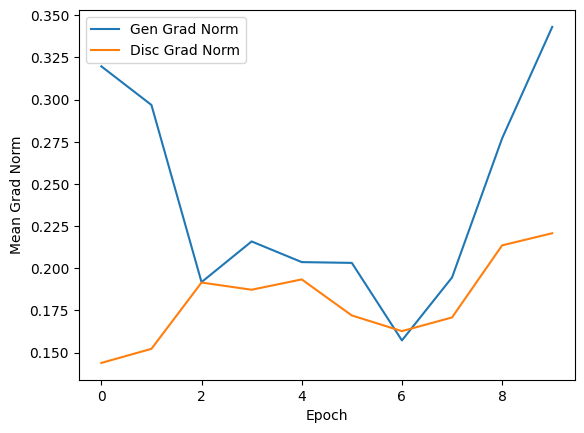

In [ ]:
plot_loss()
plot_mean_grad()

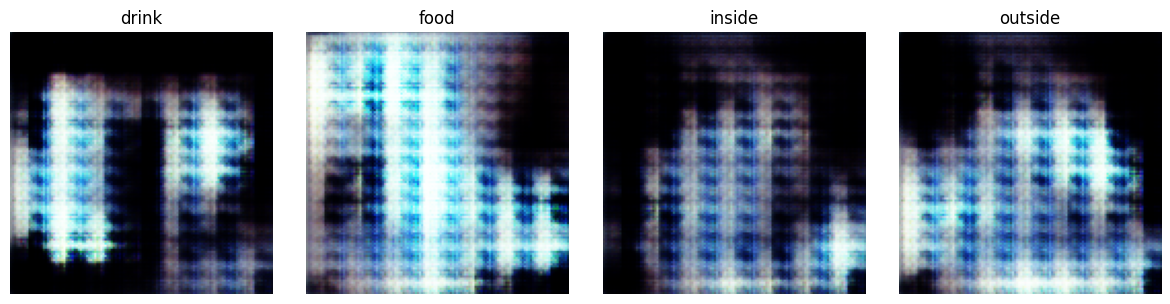

In [45]:
generate_images_by_label(generator, class_names)

As a part of tuning iteration 1, to prevent the discriminator from being overconfident in distinguishing real from fake images, we are using **label smoothing** which will **label the target 0.9 instead of 1.0**. 

As a result, even if we do label smoothing the training is stable and the **discriminator gradients have become more balanced with the generator**.

#### **Tuning iteration 2: Lowering the DropOut**

In [46]:
def build_discriminator(num_classes=NUM_CLASSES, img_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    image_input = layers.Input(shape=img_shape)
    label_input = layers.Input(shape=(1,), dtype='int32')

    label_embedding = layers.Embedding(num_classes, img_shape[0] * img_shape[1])(label_input)
    label_embedding = layers.Reshape((img_shape[0], img_shape[1], 1))(label_embedding)

    x = layers.Concatenate()([image_input, label_embedding])

    x = layers.Conv2D(64, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.1)(x)

    x = layers.Conv2D(128, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.1)(x)

    x = layers.Conv2D(256, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.1)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1, activation='sigmoid')(x)

    return models.Model([image_input, label_input], x, name="Discriminator")


In [47]:
discriminator = build_discriminator()
generator = build_generator()

gen_optimizer = tf.keras.optimizers.Adam(1e-4)
disc_optimizer = tf.keras.optimizers.Adam(1e-4)

In [ ]:
gen_loss, disc_loss, gen_grad, disc_grad = train(train_ds, EPOCHS)

Epoch 1/10 | Gen Loss: 2.8081 | Disc Loss: 0.6339 | Gen Grad: 0.205417 | Disc Grad: 0.331549 | Time: 416.62s
Epoch 2/10 | Gen Loss: 2.6861 | Disc Loss: 0.4404 | Gen Grad: 0.219892 | Disc Grad: 0.178235 | Time: 459.23s
Epoch 3/10 | Gen Loss: 2.4561 | Disc Loss: 0.4950 | Gen Grad: 0.134357 | Disc Grad: 0.269208 | Time: 526.28s
Epoch 4/10 | Gen Loss: 2.1558 | Disc Loss: 0.6618 | Gen Grad: 0.105850 | Disc Grad: 0.256085 | Time: 536.60s
Epoch 5/10 | Gen Loss: 2.6526 | Disc Loss: 0.5230 | Gen Grad: 0.117655 | Disc Grad: 0.310343 | Time: 512.22s
Epoch 6/10 | Gen Loss: 2.7685 | Disc Loss: 0.4391 | Gen Grad: 0.109713 | Disc Grad: 0.303663 | Time: 449.48s
Epoch 7/10 | Gen Loss: 2.7693 | Disc Loss: 0.5594 | Gen Grad: 0.138761 | Disc Grad: 0.434081 | Time: 471.36s
Epoch 8/10 | Gen Loss: 2.5772 | Disc Loss: 0.7095 | Gen Grad: 0.157786 | Disc Grad: 0.356180 | Time: 467.31s
Epoch 9/10 | Gen Loss: 2.6234 | Disc Loss: 0.6006 | Gen Grad: 0.228049 | Disc Grad: 0.320066 | Time: 485.39s
Epoch 10/10 | Gen L

✅ Generator model saved to: cgan_generator_final_balanced.h5


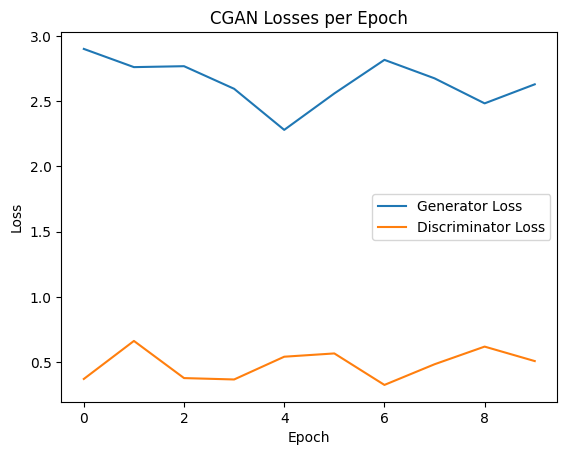

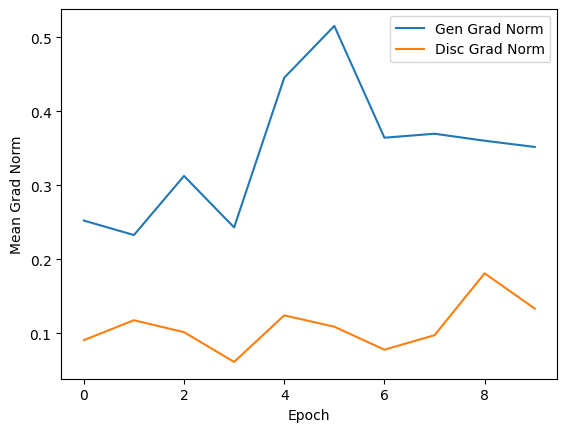

In [55]:
plot_loss()
plot_mean_grad()

As a part of our second iteration of tuning, we are **lowering the dropout from 0.3 to 0.1** to improve the **feedback loop for the generator**.

As a result, lowering dropout has **improved the flow of gradients in the discriminator** and the discriminator is **learning more actively**.